In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [7]:
#### reading dataset
df=pd.read_csv('Cardiotocographic.csv')
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [9]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [10]:
df.LB.median()

133.0

In [11]:
df.AC.median()

0.001633991

In [12]:
df['DS'].median()

0.0

In [13]:
df['DP'].median()

0.0

In [14]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [15]:
df.fillna({'LB':df.LB.median(),'AC':df.AC.median(),'DS':df.DS.median(),'DP':df.DP.median(),'MLTV':df.MLTV.median(),'Width':df.Width.median(),'Tendency':df.Tendency.median(),'NSP':df.NSP.median()},inplace=True)

In [16]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [17]:
#### checking duplicates and deletes if present
df.duplicated().sum()

np.int64(2)

In [18]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2124 non-null   float64
 1   AC        2124 non-null   float64
 2   FM        2124 non-null   float64
 3   UC        2124 non-null   float64
 4   DL        2124 non-null   float64
 5   DS        2124 non-null   float64
 6   DP        2124 non-null   float64
 7   ASTV      2124 non-null   float64
 8   MSTV      2124 non-null   float64
 9   ALTV      2124 non-null   float64
 10  MLTV      2124 non-null   float64
 11  Width     2124 non-null   float64
 12  Tendency  2124 non-null   float64
 13  NSP       2124 non-null   float64
dtypes: float64(14)
memory usage: 232.4 KB


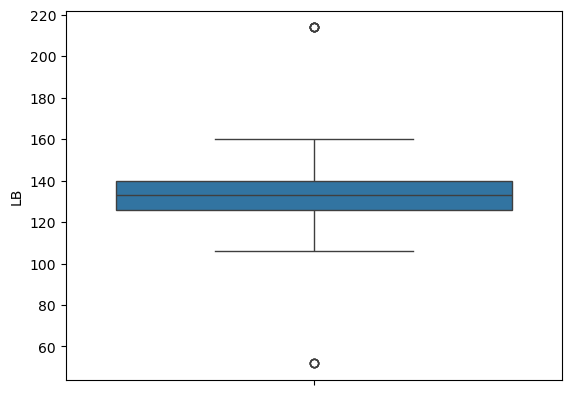

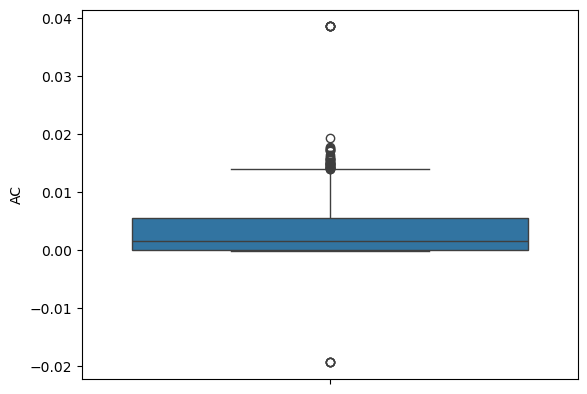

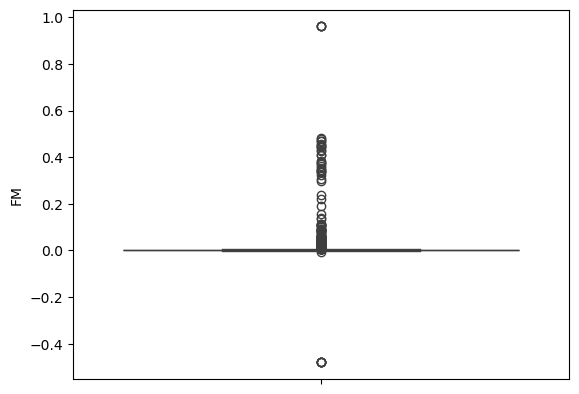

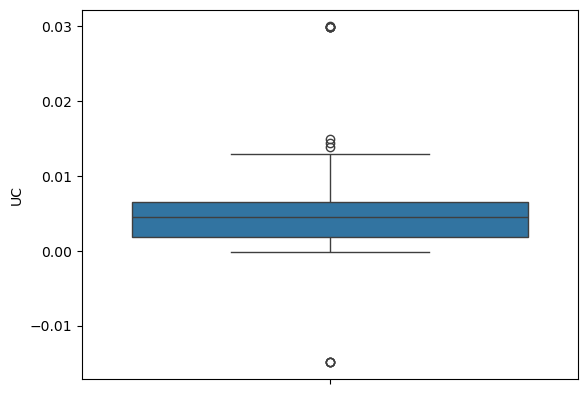

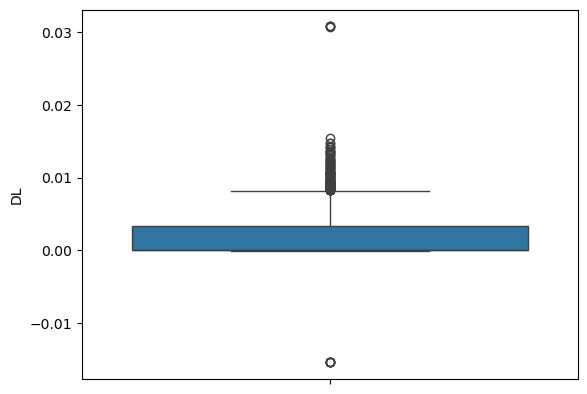

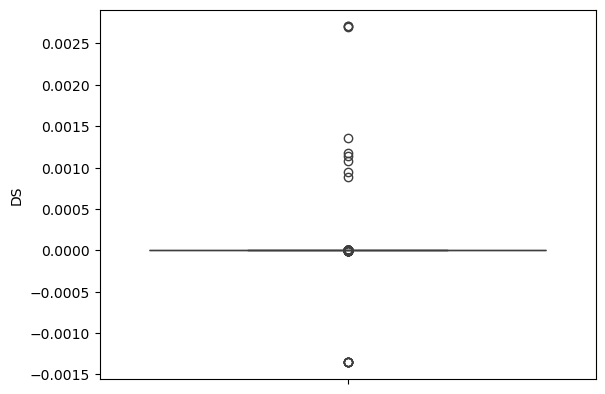

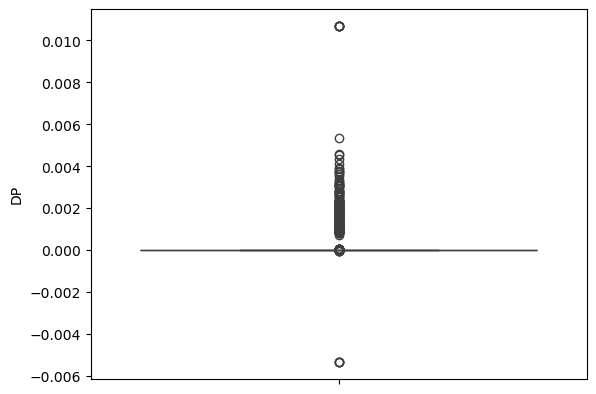

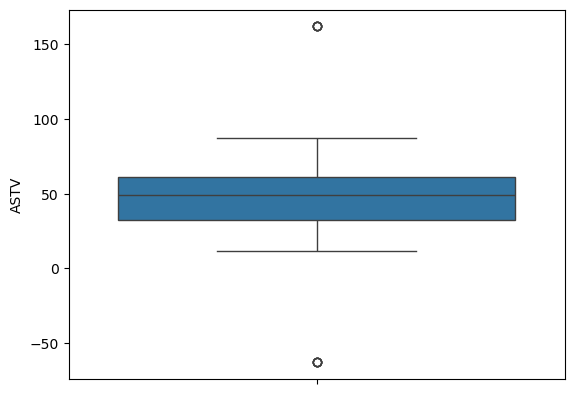

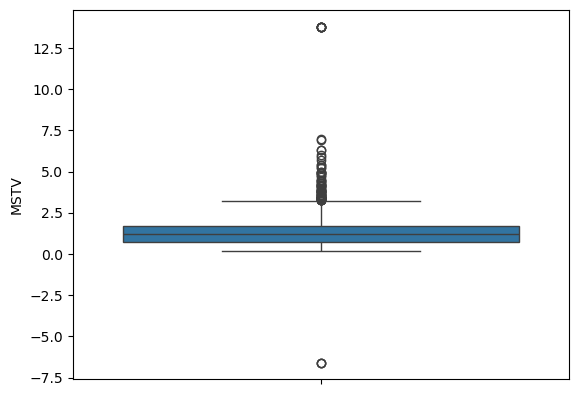

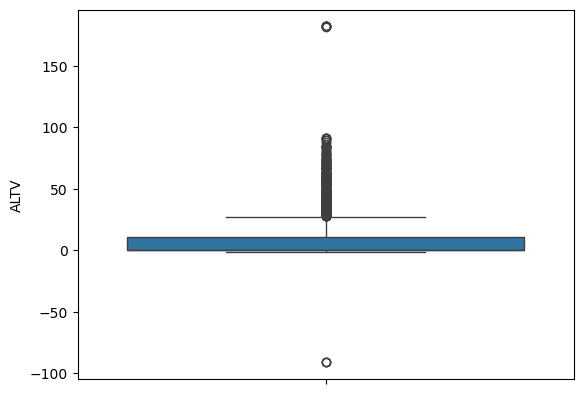

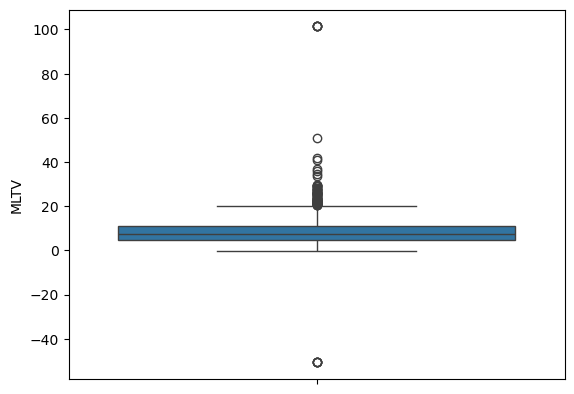

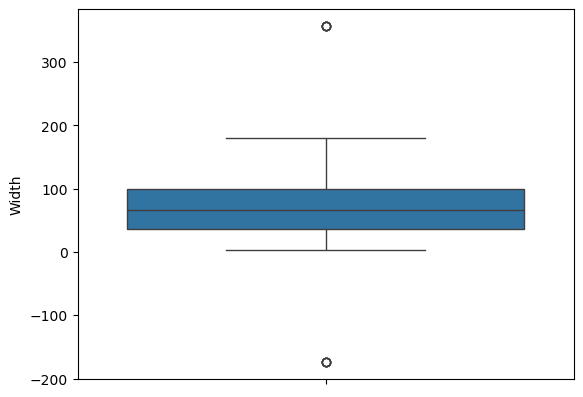

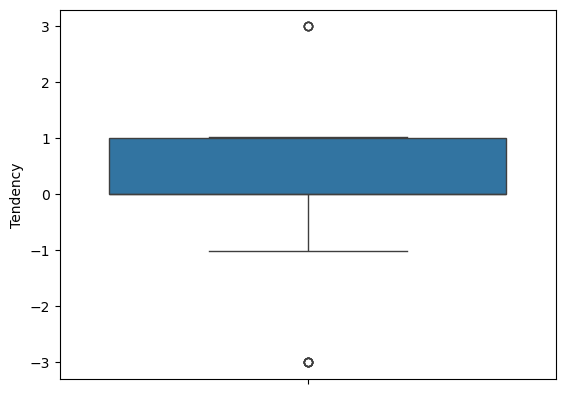

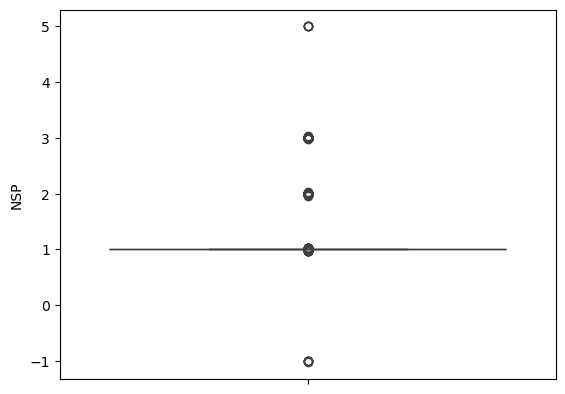

In [21]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [22]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

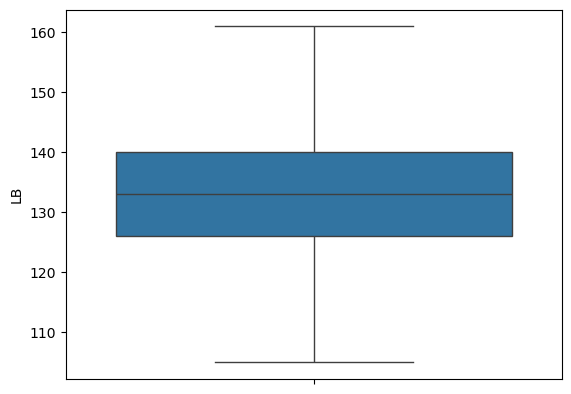

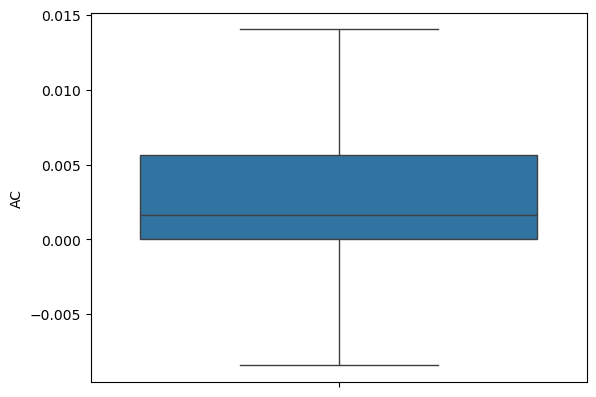

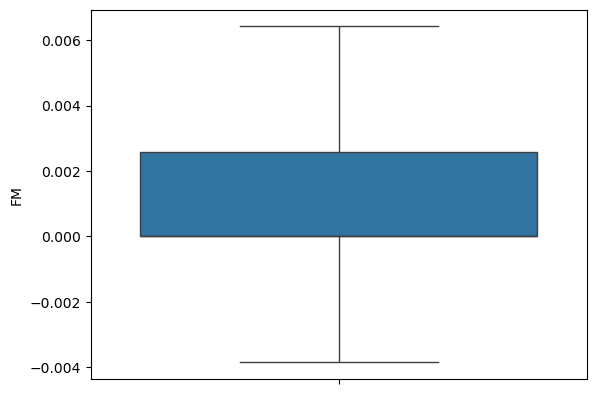

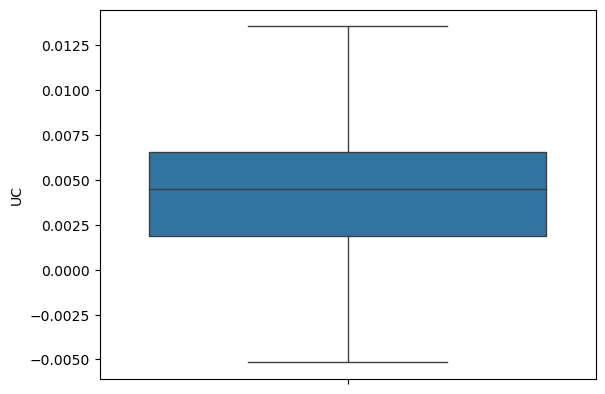

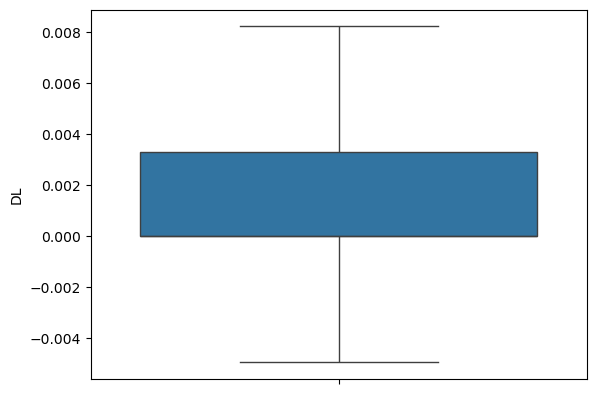

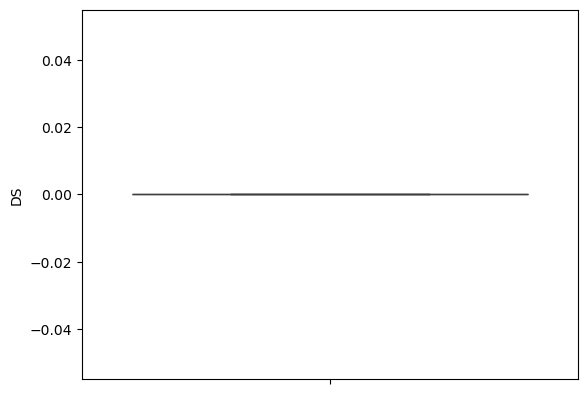

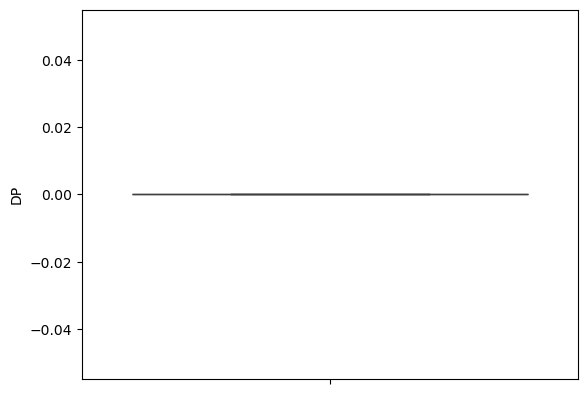

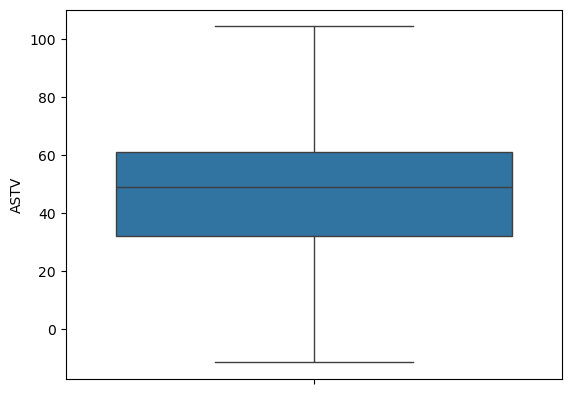

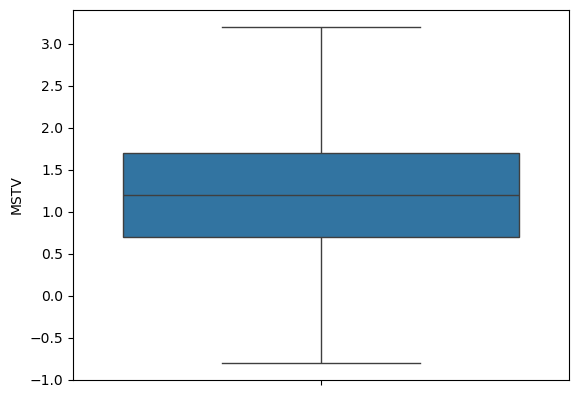

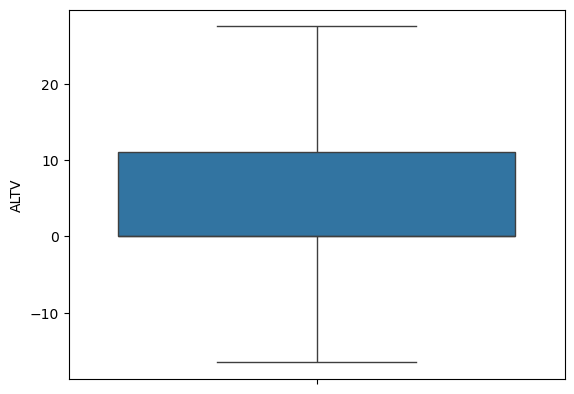

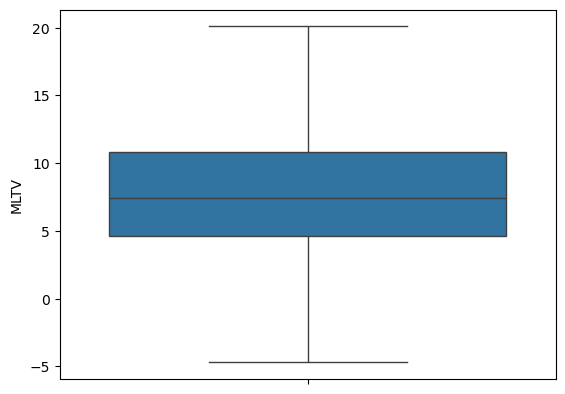

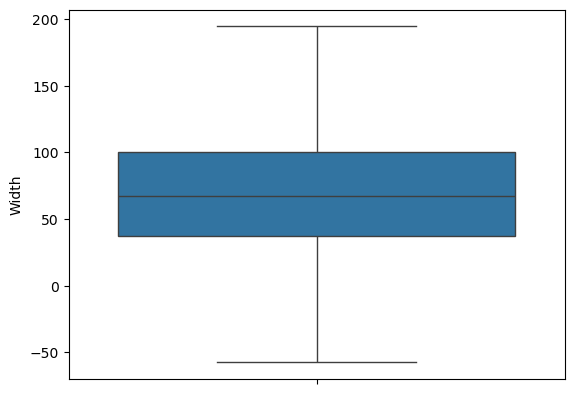

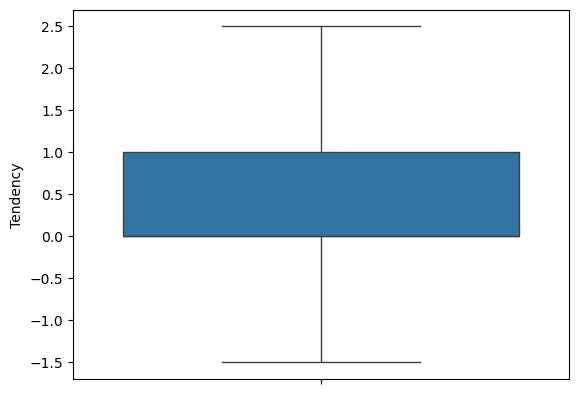

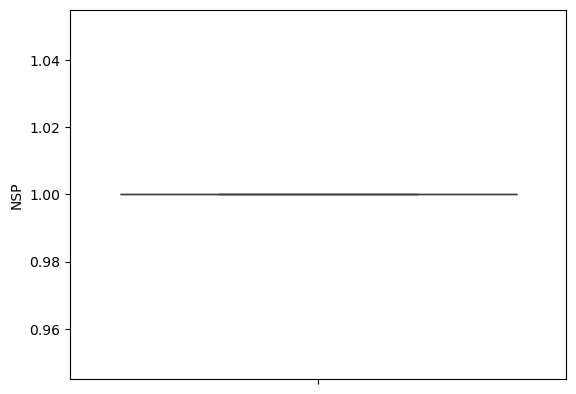

In [23]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [27]:
corr=df.corr() 
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.081548,-0.006840,-0.163345,-0.156314,NaN,NaN,0.285464,-0.295132,0.322864,-0.042241,-0.139978,0.281144,NaN
AC,-0.081548,1.000000,0.075611,0.093222,-0.103258,NaN,NaN,-0.273189,0.216861,-0.408246,-0.151713,0.283750,0.030489,NaN
FM,-0.006840,0.075611,1.000000,-0.318156,-0.018024,NaN,NaN,0.155798,0.070412,-0.013820,-0.036439,0.164178,0.000302,NaN
UC,-0.163345,0.093222,-0.318156,1.000000,0.268151,NaN,NaN,-0.217484,0.298462,-0.294226,-0.073152,0.131010,-0.074729,NaN
DL,-0.156314,-0.103258,-0.018024,0.268151,1.000000,NaN,NaN,-0.112289,0.566625,-0.296383,-0.242345,0.514238,0.014025,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.285464,-0.273189,0.155798,-0.217484,-0.112289,NaN,NaN,1.000000,-0.433731,0.438800,-0.323930,-0.242111,-0.010237,NaN
MSTV,-0.295132,0.216861,0.070412,0.298462,0.566625,NaN,NaN,-0.433731,1.000000,-0.541296,0.010734,0.646155,-0.064696,NaN
ALTV,0.322864,-0.408246,-0.013820,-0.294226,-0.296383,NaN,NaN,0.438800,-0.541296,1.000000,-0.132584,-0.439604,0.052204,NaN


<Axes: >

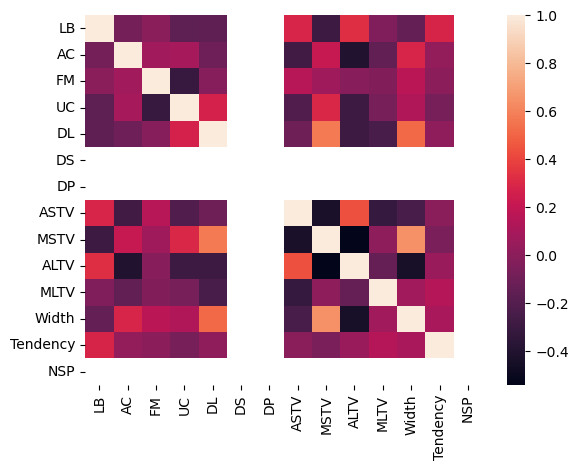

In [28]:
sns.heatmap(corr,annot=False)

In [29]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0,2124.0,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0
mean,133.288721,0.003133,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.002912,70.318547,0.316835,1.0
std,9.926790,0.003830,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.046792,39.577385,0.622623,0.0
min,105.000000,-0.008418,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014030,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [30]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [31]:
target=df[['NSP']] 
features=df.drop(columns=['NSP'])

In [32]:
features.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,27.5,2.4,64.0,0.999926
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,20.1,117.0,1.000000
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000


In [33]:
target.head()

,NSP
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


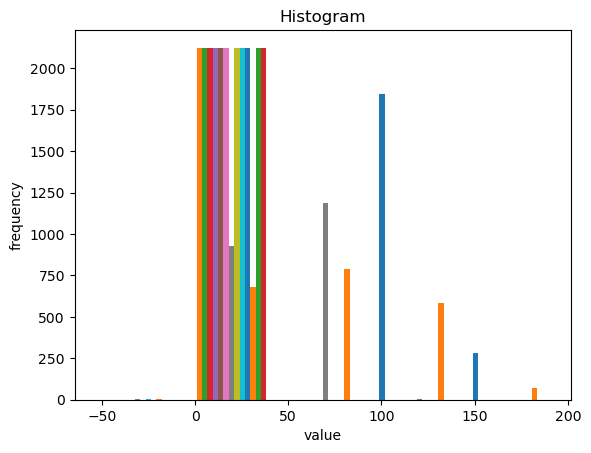

In [38]:
#### histogram
plt.hist(df,bins=5)
plt.title('Histogram')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

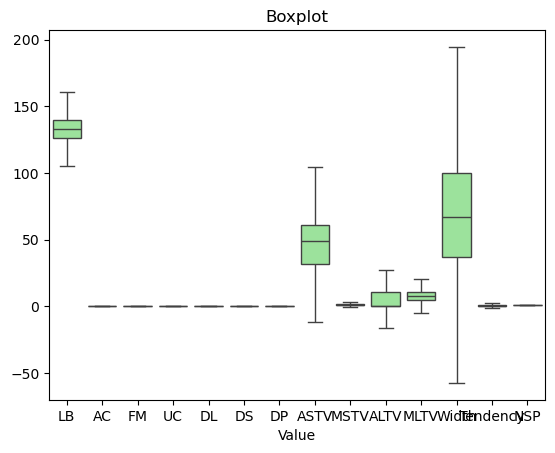

In [45]:
### boxplot
sns.boxplot(df, color='lightgreen')
plt.title("Boxplot")
plt.xlabel("Value")
plt.show()

<Axes: >

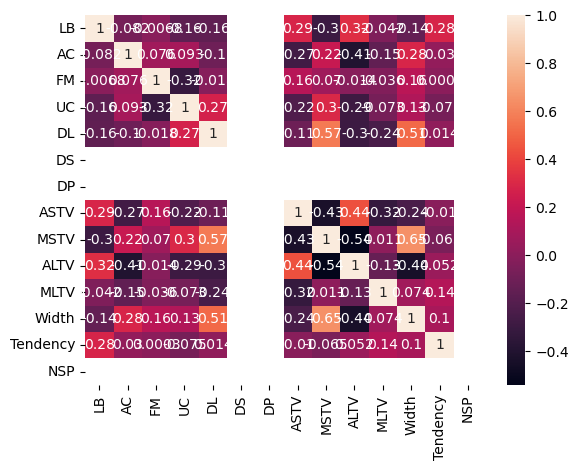

In [46]:
#### correlation heatmaps which explores the relationship between the pair of variables
sns.heatmap(corr,annot=True)

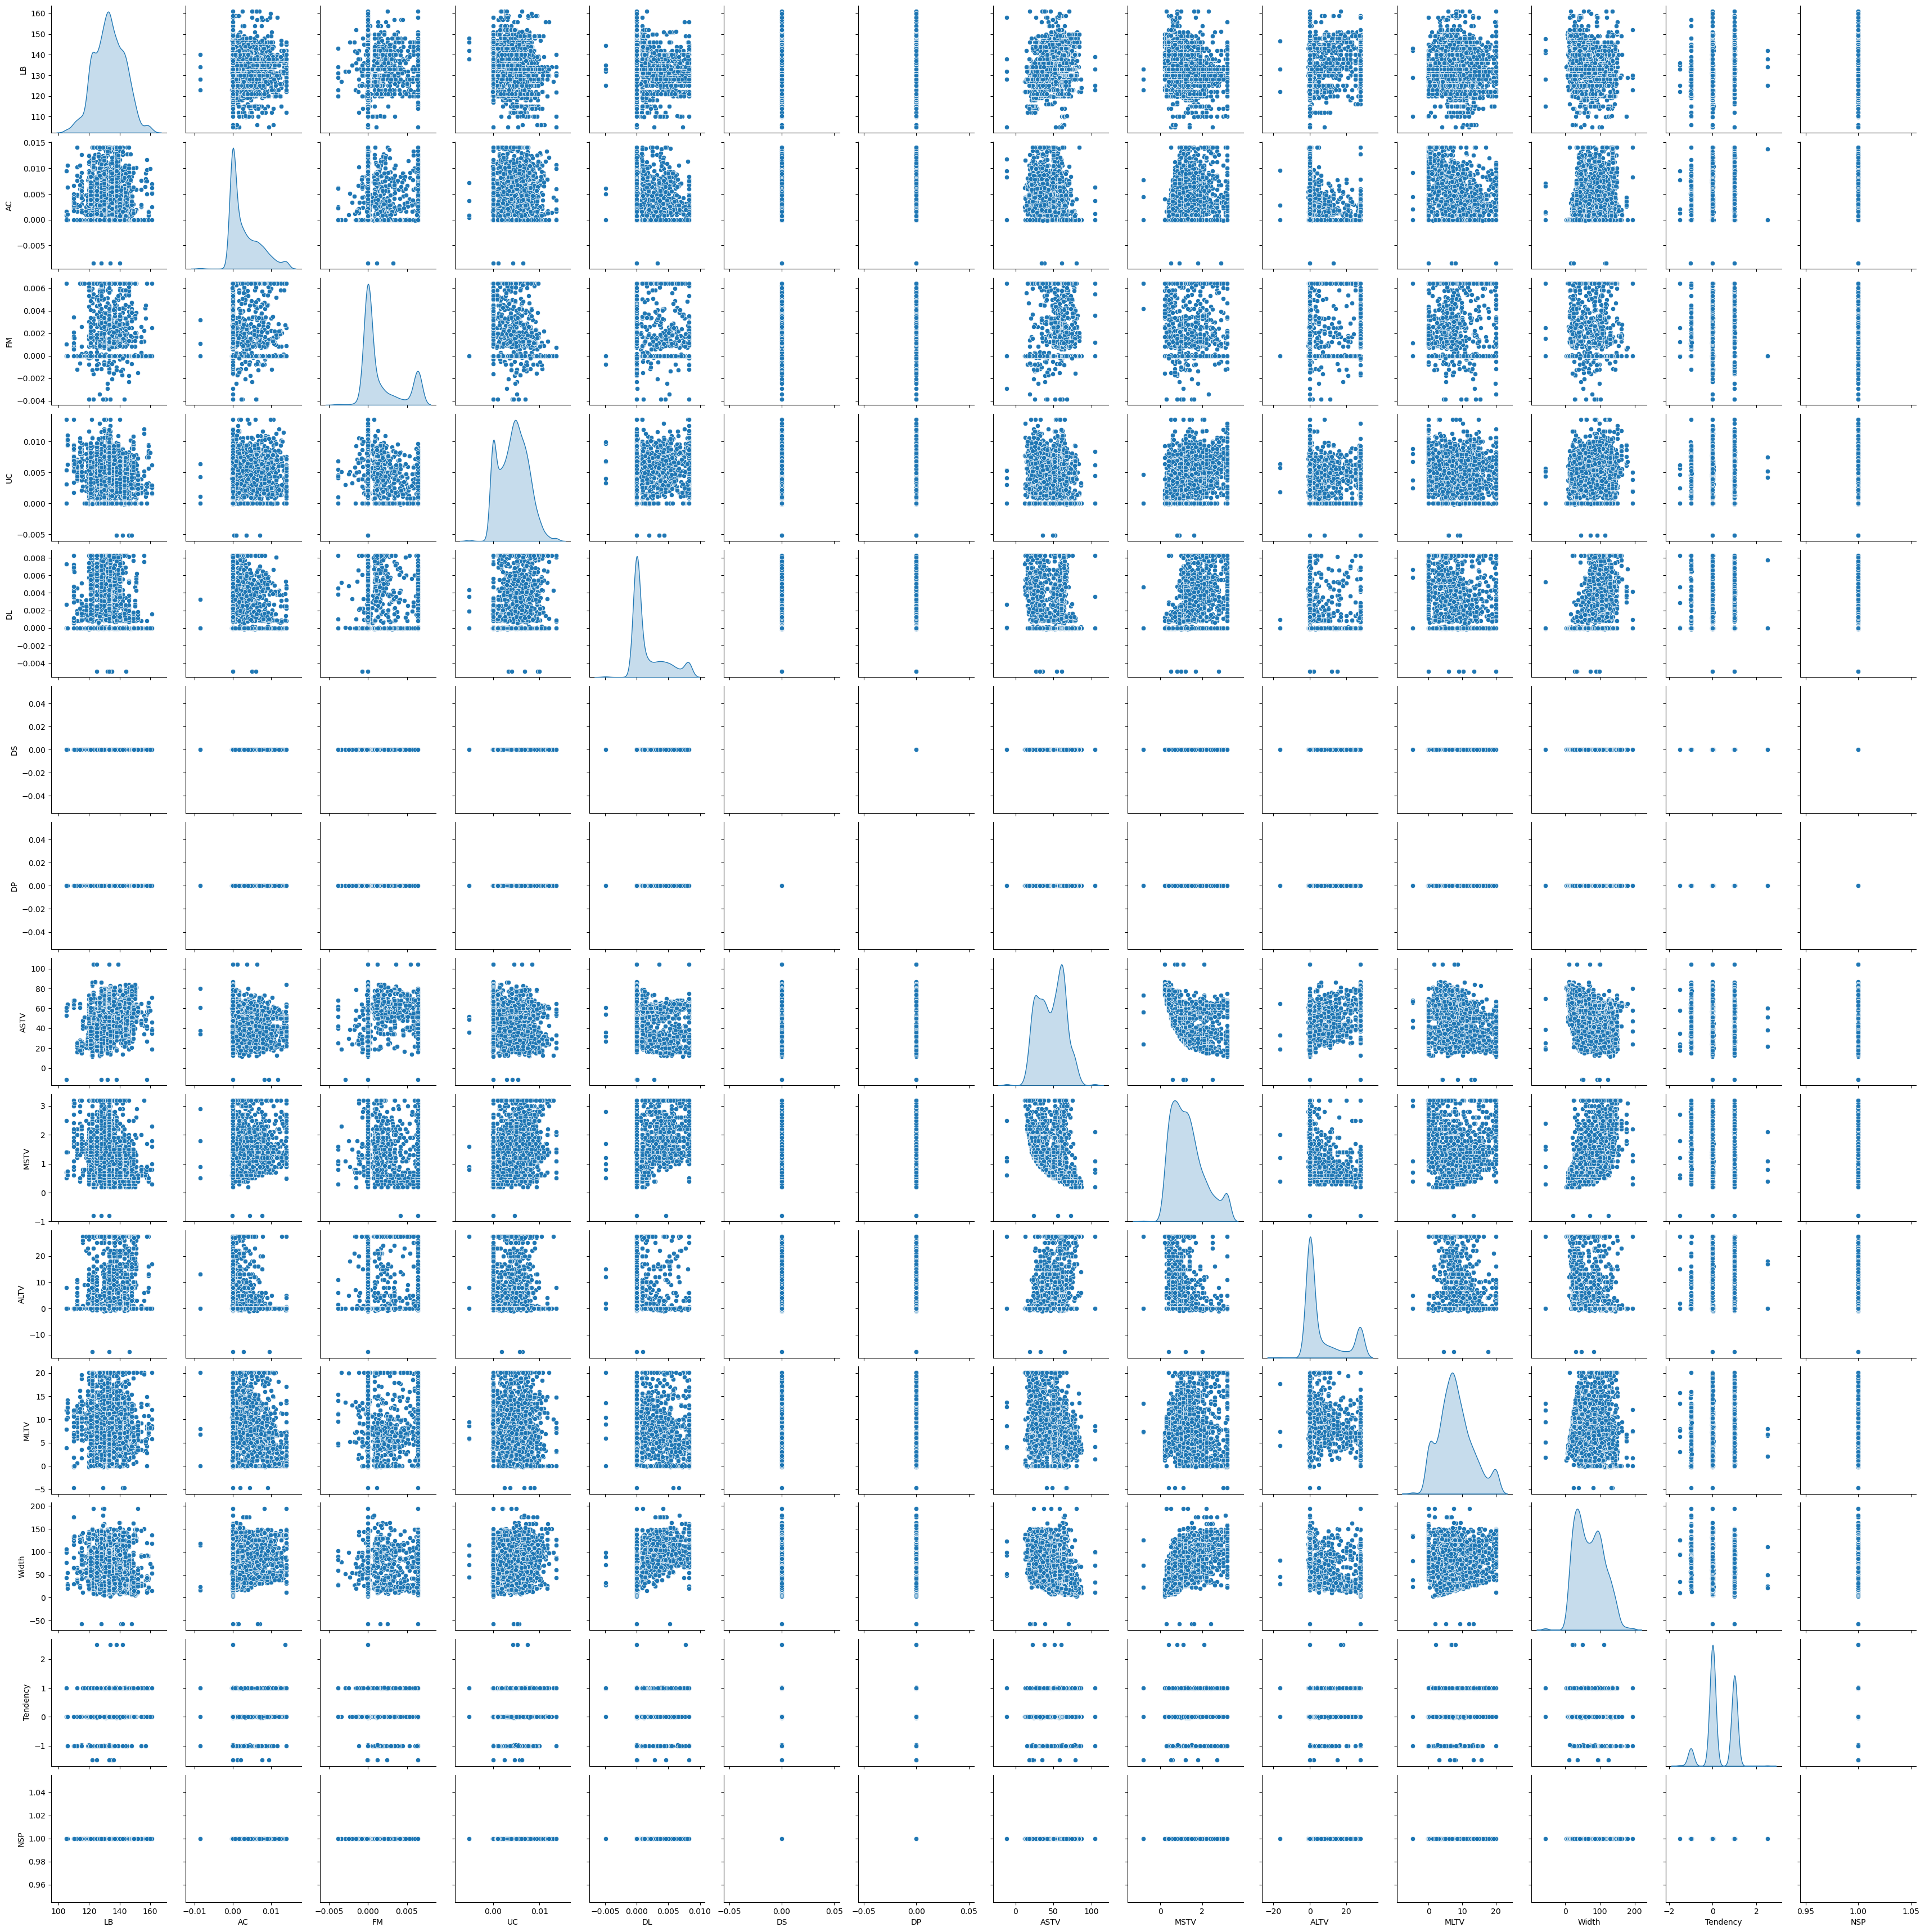

In [48]:
#### pair plot of dataset
sns.pairplot(df,diag_kind='kde')
plt.show()

C:\Users\rakes\AppData\Local\Temp\ipykernel_16288\3470171875.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="NSP", y="LB", data=df, palette="Set2")


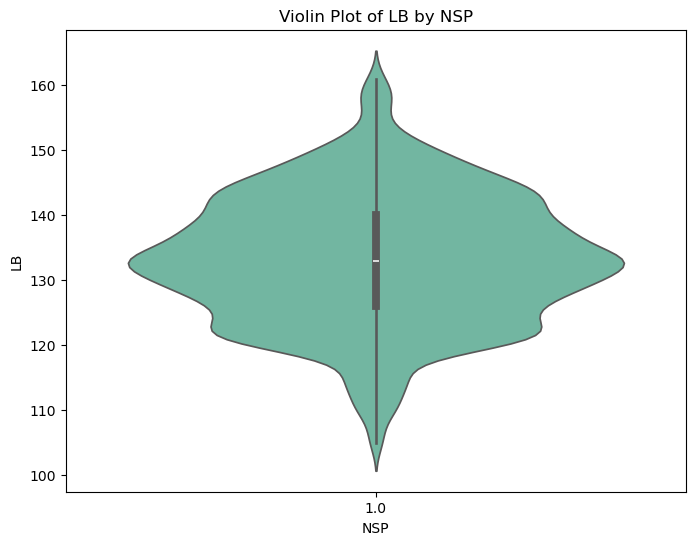

In [51]:
### violin plot for deeper insights
plt.figure(figsize=(8, 6))
sns.violinplot(x="NSP", y="LB", data=df, palette="Set2")
plt.title("Violin Plot of LB by NSP")
plt.show()
